# Introduction to pandas

* **pandas** is a Python package providing convenient data structures to work with labelled data.

* **pandas** is perfectly suited for observational / statistical data sets, having many similarities with Excel spreadsheets.

* Key features:

    - easy handling of **missing data**
    - **size mutability**: columns can be inserted and deleted from DataFrame
    - automatic and explicit **data alignment**: objects can be explicitly aligned to a set of labels, or the user can simply ignore the labels and let Series, DataFrame, etc. automatically align the data for you in computations
    - powerful, flexible **group by** functionality to perform split-apply-combine operations on data sets
    - make it **easy to convert** ragged, differently-indexed data in other Python and NumPy data structures into DataFrame objects
    - intelligent label-based **slicing**, **fancy indexing**, and **subsetting** of large data sets
    - intuitive **merging** and **joining** data sets
    - flexible **reshaping** and pivoting of data sets
    - **hierarchical** labeling of axes (possible to have multiple labels per tick)
    - robust IO tools for loading data from **flat files** (CSV and delimited), Excel files, databases, and saving / loading data from the ultrafast HDF5 format
    - **time series**-specific functionality

### Primary data structures of pandas
* **Series** (1-dimensional)
* **DataFrame** (2-dimensional)

pandas is built on top of **NumPy** and is intended to integrate well within a scientific computing environment with many other 3rd party libraries.

## Loading data

* In this part, we will use observations of the air quality as an example
* The data have been collected **hourly** from one of the monitoring sites in London (Marleybone Road) **over the year 2015**
* Measured are: ozone ($O_3$), nitrogen oxides (NOx), carbon monoxide (CO) and PM10 particulate matter

* Data source: https://uk-air.defra.gov.uk/data/
* Site description: https://uk-air.defra.gov.uk/networks/site-info?uka_id=UKA00315

First, we import pandas module. We use an alias "pd" to write code quicker.

In [1]:
import pandas as pd

We also import the `os` module that is useful for building paths to files (among many other things). And `numpy` with `matplotlib` just in case too.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

In [3]:
import warnings
#warnings.filterwarnings('ignore')

In [4]:
fname = '../data/air_quality_hourly_london_marylebone.csv'

Let's try to read the data using `pandas.read_csv()` function.

In [5]:
# minimal setup to read the given file
air_quality = pd.read_csv(fname, header=4, skipfooter=4, na_values='No data', engine='python')

**Q**: What happens if you remove the header? skipfooter? engine?

## Data structures: `DataFrame` and `Series`

Let's interrogate the `DataFrame` object!

In [6]:
type(air_quality)

pandas.core.frame.DataFrame

In [7]:
# Internal nature of the object
print(air_quality.shape)
print()
print(air_quality.dtypes)

(8760, 12)

Start date                                    object
End Date                                      object
Ozone                                        float64
Status                                        object
Nitrogen oxides as nitrogen dioxide          float64
Status.1                                      object
Carbon monoxide                              float64
Status.2                                      object
PM10 particulate matter (Hourly measured)    float64
Status.3                                      object
Cobalt                                       float64
Status.4                                     float64
dtype: object


In [8]:
sys.maxsize

9223372036854775807

In [9]:
# View just the tip of data
air_quality.head(5)

# import sys
# pd.set_option("display.max_rows", sys.maxsize)
# air_quality

,Start date,End Date,Ozone,Status,Nitrogen oxides as nitrogen dioxide,Status.1,Carbon monoxide,Status.2,PM10 particulate matter (Hourly measured),Status.3,Cobalt,Status.4
0,2015-01-01,01:00:00,13.70381,V ugm-3,177.01526,V ugm-3,0.375260,V mgm-3,39.3,V ugm-3 (TEOM FDMS),NaN,NaN
1,2015-01-01,02:00:00,8.58151,V ugm-3,294.46380,V ugm-3,0.542517,V mgm-3,41.1,V ugm-3 (TEOM FDMS),NaN,NaN
2,2015-01-01,03:00:00,9.77893,V ugm-3,209.99537,V ugm-3,0.406306,V mgm-3,35.1,V ugm-3 (TEOM FDMS),NaN,NaN
3,2015-01-01,04:00:00,13.96990,V ugm-3,160.89863,V ugm-3,0.281445,V mgm-3,27.6,V ugm-3 (TEOM FDMS),NaN,NaN
4,2015-01-01,05:00:00,15.66625,V ugm-3,153.89362,V ugm-3,0.250303,V mgm-3,27.9,V ugm-3 (TEOM FDMS),NaN,NaN


**Q:** What did you notice about "Status" columns? Compare them to the original text file.

In [10]:
# View the last rows of data
air_quality.tail(n=2)  # Note the optional argument (available for head() too)

,Start date,End Date,Ozone,Status,Nitrogen oxides as nitrogen dioxide,Status.1,Carbon monoxide,Status.2,PM10 particulate matter (Hourly measured),Status.3,Cobalt,Status.4
8758,2015-12-31,23:00:00,5.63785,V ugm-3,323.28183,V ugm-3,0.842881,V mgm-3,NaN,V ugm-3 (TEOM FDMS),NaN,NaN
8759,2015-12-31,24:00:00,4.83957,V ugm-3,290.91803,V ugm-3,0.722095,V mgm-3,NaN,V ugm-3 (TEOM FDMS),NaN,NaN


Get descriptors for the **vertical** axis (axis=0):

In [11]:
air_quality.index

RangeIndex(start=0, stop=8760, step=1)

Get descriptors for the horizontal axis (axis=1):

In [12]:
air_quality.columns

Index(['Start date', 'End Date', 'Ozone', 'Status',
       'Nitrogen oxides as nitrogen dioxide', 'Status.1', 'Carbon monoxide',
       'Status.2', 'PM10 particulate matter (Hourly measured)', 'Status.3',
       'Cobalt', 'Status.4'],
      dtype='object')

A lot of information at once including memory usage:

In [13]:
air_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 12 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Start date                                 8760 non-null   object 
 1   End Date                                   8760 non-null   object 
 2   Ozone                                      8601 non-null   float64
 3   Status                                     8760 non-null   object 
 4   Nitrogen oxides as nitrogen dioxide        8640 non-null   float64
 5   Status.1                                   8760 non-null   object 
 6   Carbon monoxide                            8539 non-null   float64
 7   Status.2                                   8760 non-null   object 
 8   PM10 particulate matter (Hourly measured)  8502 non-null   float64
 9   Status.3                                   8760 non-null   object 
 10  Cobalt                  

In [14]:
air_quality['Time']

KeyError: 'Time'

### Series, pandas' 1D data containter

A series can be constructed with the `pd.Series` constructor (passing an array of values) or from a `DataFrame`, by extracting one of its columns.

In [15]:
carbon_monoxide = air_quality['Carbon monoxide']

Some of its attributes:

In [16]:
print(type(carbon_monoxide))
print(carbon_monoxide.dtype)
print(carbon_monoxide.shape)
print(carbon_monoxide.nbytes)

<class 'pandas.core.series.Series'>
float64
(8760,)
70080


Show me what you got!

In [17]:
# uncomment to see the values
# carbon_monoxide

### Numpy as pandas's backend

It is always possible to fall back to a good old NumPy array to pass on to scientific libraries that need them: SciPy, scikit-learn, etc

In [18]:
air_quality['Nitrogen oxides as nitrogen dioxide'].values

array([177.01526, 294.4638 , 209.99537, ..., 314.07697, 323.28183,
       290.91803], shape=(8760,))

In [19]:
type(air_quality['Nitrogen oxides as nitrogen dioxide'].values)

numpy.ndarray

## Cleaning data

<blockquote class="twitter-tweet" data-lang="en"><p lang="en" dir="ltr">The truth about data science: cleaning your data is 90% of the work. Fitting the model is easy. Interpreting the results is the other 90%.</p>&mdash; Jake VanderPlas (@jakevdp) <a href="https://twitter.com/jakevdp/status/742406386525446144">June 13, 2016</a></blockquote>
<script async src="//platform.twitter.com/widgets.js" charset="utf-8"></script>

### Dealing with dates and times

In [20]:
air_quality = pd.read_csv(fname, header=4, skipfooter=4, na_values='No data', engine='python',
              parse_dates={'Time': [0, 1]})#, date_parser=dateparse) 
air_quality.head(4)

C:\Users\tams00\AppData\Local\Temp\ipykernel_94028\3002522357.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  air_quality = pd.read_csv(fname, header=4, skipfooter=4, na_values='No data', engine='python',


,Time,Ozone,Status,Nitrogen oxides as nitrogen dioxide,Status.1,Carbon monoxide,Status.2,PM10 particulate matter (Hourly measured),Status.3,Cobalt,Status.4
0,2015-01-01 01:00:00,13.70381,V ugm-3,177.01526,V ugm-3,0.375260,V mgm-3,39.3,V ugm-3 (TEOM FDMS),NaN,NaN
1,2015-01-01 02:00:00,8.58151,V ugm-3,294.46380,V ugm-3,0.542517,V mgm-3,41.1,V ugm-3 (TEOM FDMS),NaN,NaN
2,2015-01-01 03:00:00,9.77893,V ugm-3,209.99537,V ugm-3,0.406306,V mgm-3,35.1,V ugm-3 (TEOM FDMS),NaN,NaN
3,2015-01-01 04:00:00,13.96990,V ugm-3,160.89863,V ugm-3,0.281445,V mgm-3,27.6,V ugm-3 (TEOM FDMS),NaN,NaN


The Time column  looks fine, but looking inot the datatypes, we can see that Time is an "object" which in pandas its means that it did not manage to convert to datetime object.
This is due to incorrect 24:00:00 times in the file.

In [21]:
print(air_quality.dtypes)

Time                                          object
Ozone                                        float64
Status                                        object
Nitrogen oxides as nitrogen dioxide          float64
Status.1                                      object
Carbon monoxide                              float64
Status.2                                      object
PM10 particulate matter (Hourly measured)    float64
Status.3                                      object
Cobalt                                       float64
Status.4                                     float64
dtype: object


A specific parse can be created to deal with tricky inputs.

Here we are adding 1 day to the datetime object, if the time text mmatches the erroneous 24:00:00

In [22]:
import datetime
def dateparse(datetime_str):
    date_str, time_str = datetime_str.split()
    if time_str == '24:00:00':
        time_str = '00:00:00'
        date = datetime.datetime.strptime(date_str + ' ' + time_str, '%Y-%m-%d %H:%M:%S')
        date = date + datetime.timedelta(days=1)
    else:
        date = datetime.datetime.strptime(date_str + ' ' + time_str, '%Y-%m-%d %H:%M:%S')
    return date

In [23]:
air_quality = pd.read_csv(fname, header=4, skipfooter=4, na_values='No data', engine='python',
                          parse_dates={'Time': [0, 1]}, date_parser=dateparse)
print(air_quality.dtypes)
air_quality.head(4)

C:\Users\tams00\AppData\Local\Temp\ipykernel_94028\3704037294.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  air_quality = pd.read_csv(fname, header=4, skipfooter=4, na_values='No data', engine='python',
C:\Users\tams00\AppData\Local\Temp\ipykernel_94028\3704037294.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  air_quality = pd.read_csv(fname, header=4, skipfooter=4, na_values='No data', engine='python',


Time                                         datetime64[ns]
Ozone                                               float64
Status                                               object
Nitrogen oxides as nitrogen dioxide                 float64
Status.1                                             object
Carbon monoxide                                     float64
Status.2                                             object
PM10 particulate matter (Hourly measured)           float64
Status.3                                             object
Cobalt                                              float64
Status.4                                            float64
dtype: object


,Time,Ozone,Status,Nitrogen oxides as nitrogen dioxide,Status.1,Carbon monoxide,Status.2,PM10 particulate matter (Hourly measured),Status.3,Cobalt,Status.4
0,2015-01-01 01:00:00,13.70381,V ugm-3,177.01526,V ugm-3,0.375260,V mgm-3,39.3,V ugm-3 (TEOM FDMS),NaN,NaN
1,2015-01-01 02:00:00,8.58151,V ugm-3,294.46380,V ugm-3,0.542517,V mgm-3,41.1,V ugm-3 (TEOM FDMS),NaN,NaN
2,2015-01-01 03:00:00,9.77893,V ugm-3,209.99537,V ugm-3,0.406306,V mgm-3,35.1,V ugm-3 (TEOM FDMS),NaN,NaN
3,2015-01-01 04:00:00,13.96990,V ugm-3,160.89863,V ugm-3,0.281445,V mgm-3,27.6,V ugm-3 (TEOM FDMS),NaN,NaN


### Renaming columns

In [24]:
air_quality.columns = ['Time', 'O3', 'O3_status', 'NOx', 'NOx_status',
                       'CO', 'CO_status', 'PM10', 'PM10_status', 'Co', 'Co_status']
air_quality.columns

Index(['Time', 'O3', 'O3_status', 'NOx', 'NOx_status', 'CO', 'CO_status',
       'PM10', 'PM10_status', 'Co', 'Co_status'],
      dtype='object')

### Deleting columns

Let us concentrate our attention on the first 4 chemical species, and remove cobalt data from our `DataFrame`:

In [25]:
air_quality

,Time,O3,O3_status,NOx,NOx_status,CO,CO_status,PM10,PM10_status,Co,Co_status
0,2015-01-01 01:00:00,13.70381,V ugm-3,177.01526,V ugm-3,0.375260,V mgm-3,39.3,V ugm-3 (TEOM FDMS),NaN,NaN
1,2015-01-01 02:00:00,8.58151,V ugm-3,294.46380,V ugm-3,0.542517,V mgm-3,41.1,V ugm-3 (TEOM FDMS),NaN,NaN
2,2015-01-01 03:00:00,9.77893,V ugm-3,209.99537,V ugm-3,0.406306,V mgm-3,35.1,V ugm-3 (TEOM FDMS),NaN,NaN
3,2015-01-01 04:00:00,13.96990,V ugm-3,160.89863,V ugm-3,0.281445,V mgm-3,27.6,V ugm-3 (TEOM FDMS),NaN,NaN
4,2015-01-01 05:00:00,15.66625,V ugm-3,153.89362,V ugm-3,0.250303,V mgm-3,27.9,V ugm-3 (TEOM FDMS),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8755,2015-12-31 20:00:00,10.12818,V ugm-3,349.70684,V ugm-3,0.782342,V mgm-3,NaN,V ugm-3 (TEOM FDMS),NaN,NaN
8756,2015-12-31 21:00:00,7.78323,V ugm-3,354.99203,V ugm-3,0.903128,V mgm-3,NaN,V ugm-3 (TEOM FDMS),NaN,NaN
8757,2015-12-31 22:00:00,8.43183,V ugm-3,314.07697,V ugm-3,0.842590,V mgm-3,NaN,V ugm-3 (TEOM FDMS),NaN,NaN
8758,2015-12-31 23:00:00,5.63785,V ugm-3,323.28183,V ugm-3,0.842881,V mgm-3,NaN,V ugm-3 (TEOM FDMS),NaN,NaN


In [26]:
air_quality.drop('Co', axis=1, inplace=True)
air_quality.drop('Co_status', axis=1)
air_quality.head(4)

,Time,O3,O3_status,NOx,NOx_status,CO,CO_status,PM10,PM10_status,Co_status
0,2015-01-01 01:00:00,13.70381,V ugm-3,177.01526,V ugm-3,0.375260,V mgm-3,39.3,V ugm-3 (TEOM FDMS),NaN
1,2015-01-01 02:00:00,8.58151,V ugm-3,294.46380,V ugm-3,0.542517,V mgm-3,41.1,V ugm-3 (TEOM FDMS),NaN
2,2015-01-01 03:00:00,9.77893,V ugm-3,209.99537,V ugm-3,0.406306,V mgm-3,35.1,V ugm-3 (TEOM FDMS),NaN
3,2015-01-01 04:00:00,13.96990,V ugm-3,160.89863,V ugm-3,0.281445,V mgm-3,27.6,V ugm-3 (TEOM FDMS),NaN


## Basic visualisation

Try calling `plot()` method of the `air_quality` object:

<Axes: >

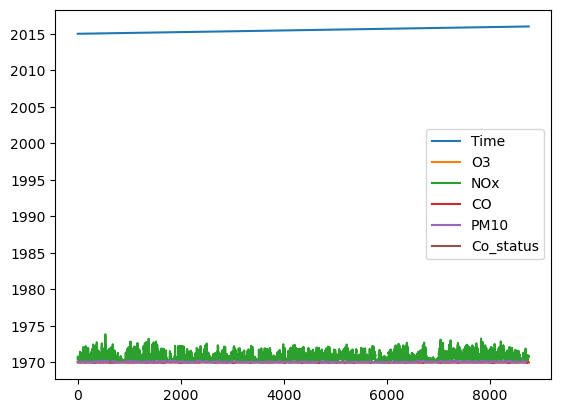

In [27]:
air_quality.plot()

What happens if put `subplots=True` as an argument of the `plot()` method?

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

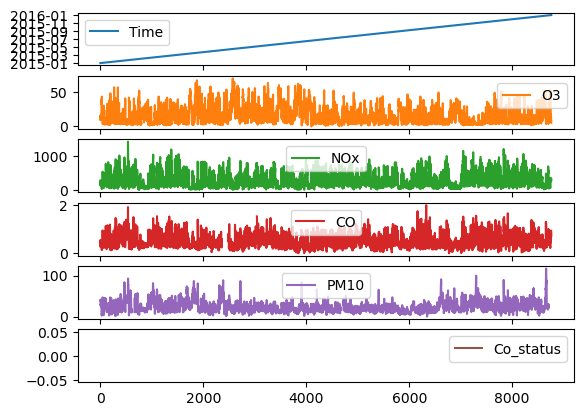

In [28]:
air_quality.plot( subplots=True )

It is easy to create other useful plots using `DataFrame`:

<Axes: ylabel='Density'>

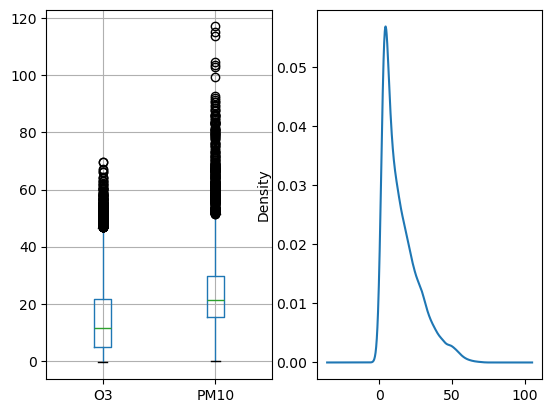

In [29]:
fig, (ax0, ax1) = plt.subplots(ncols=2)
air_quality.boxplot(ax=ax0, column=['O3', 'PM10'])
air_quality['O3'].plot(ax=ax1, kind="kde")

**Q:** the plot is too small. How to make it bigger?

As well as just a simple line plot:

Text(0.5, 1.0, 'O3')

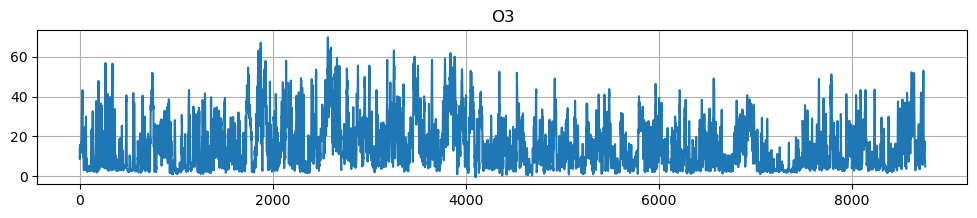

In [30]:
ax = air_quality['O3'].plot(grid=True, figsize=(12, 2))
ax.set_title('O3')

### Setting missing values

As you may notice, we have negative values of ozone concentration, which does not make sense. So, let us replace those negative values with NaN:

**Q:** how to list data entries with negative O3?

In [31]:
# your code here

We can mask them out in the same way as you do with numpy arrays:

In [32]:
# Replace negative ozone values with NaN

## Saving data

For each `read_**` function to load data, there is a `to_**` method attached to `Series` and `DataFrames`.

#### Excel spreadsheets

Uncomment the following code cell and run to save the whole `DataFrame` to an Excel file.

In [33]:
with pd.ExcelWriter("test.xls") as our_writer:
     air_quality.to_excel(our_writer, sheet_name='Blah-blah')

ValueError: No engine for filetype: 'xls'

In [34]:
air_quality.to_excel("path_to_file.xls", engine="openpyxl")

#### Exercise: writing to CSV text files

Find a method to save `DataFrames` to a text file (or whatever format you like more).

In [37]:
# Your code here


## Some statistics

In [38]:
air_quality.describe()

,Time,O3,NOx,CO,PM10,Co_status
count,8760,8601.000000,8640.000000,8539.000000,8502.000000,0.0
mean,2015-07-02 12:30:00,15.106245,298.584537,0.508970,24.098553,NaN
min,2015-01-01 01:00:00,-0.548820,18.447340,0.000000,0.000000,NaN
25%,2015-04-02 06:45:00,5.039140,135.326110,0.324230,15.200000,NaN
50%,2015-07-02 12:30:00,11.425380,241.762950,0.468008,21.500000,NaN
75%,2015-10-01 18:15:00,21.703240,431.754645,0.661994,29.700000,NaN
max,2016-01-01 00:00:00,69.749710,1409.545970,1.978267,117.100000,NaN
std,NaN,12.428715,205.757696,0.248388,13.043507,NaN


## Computing correlations

Both `Series` and `DataFrames` have a **`corr()`** method to compute the correlation coefficient.

In [39]:
air_quality.NOx.corr(air_quality['CO'])

np.float64(0.7712297105293433)

If series are already grouped into a `DataFrame`, computing all correlation coefficients is trivial:

In [40]:
# First remove any non-numeric columns
air_quality.drop(['CO_status','PM10_status','O3_status','NOx_status'], axis=1, inplace=True)

In [41]:
air_quality.corr()

,Time,O3,NOx,CO,PM10,Co_status
Time,1.000000,-0.139662,0.076909,0.051042,0.015462,NaN
O3,-0.139662,1.000000,-0.616366,-0.562348,-0.448303,NaN
NOx,0.076909,-0.616366,1.000000,0.771230,0.529790,NaN
CO,0.051042,-0.562348,0.771230,1.000000,0.532399,NaN
PM10,0.015462,-0.448303,0.529790,0.532399,1.000000,NaN
Co_status,NaN,NaN,NaN,NaN,NaN,NaN


You can visualise this correlation matrix:

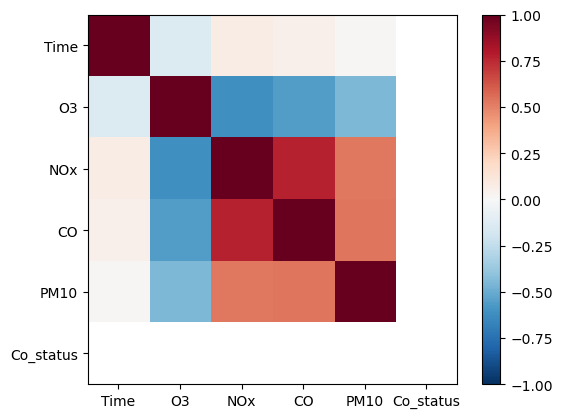

In [42]:
fig, ax = plt.subplots()
p = ax.imshow(air_quality.corr(), interpolation="nearest", cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(air_quality.corr().columns)))
ax.set_yticks(np.arange(len(air_quality.corr().index)))
ax.set_xticklabels(air_quality.corr().columns)
ax.set_yticklabels(air_quality.corr().index)
fig.colorbar(p)

## Creating DataFrames

* `DataFrame` can also be created manually, by grouping several `Series` together.
* Now just for fun we switch to **another dataset**
    - create 2 `Series` objects from 2 CSV files
    - create a `DataFrame` by combining the two `Series`

* Data are monthly values of
    - Southern Oscillation Index (SOI)
    - Outgoing Longwave Radiation (OLR), which is a proxy for convective precipitation in the western equatorial Pacific
* Data were downloaded from NOAA's website: https://www.ncdc.noaa.gov/teleconnections/

In [43]:
soi_df = pd.read_csv('../data/soi.csv', skiprows=1, parse_dates=[0], index_col=0, na_values=-999.9,
                     date_parser=lambda x: pd.to_datetime(x, format='%Y%m'))

C:\Users\tams00\AppData\Local\Temp\ipykernel_94028\1988633426.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  soi_df = pd.read_csv('../data/soi.csv', skiprows=1, parse_dates=[0], index_col=0, na_values=-999.9,


In [44]:
olr_df = pd.read_csv('../data/olr.csv', skiprows=1, parse_dates=[0], index_col=0, na_values=-999.9,
                     date_parser=lambda x: pd.to_datetime(x, format='%Y%m'))

C:\Users\tams00\AppData\Local\Temp\ipykernel_94028\210244455.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  olr_df = pd.read_csv('../data/olr.csv', skiprows=1, parse_dates=[0], index_col=0, na_values=-999.9,


In [45]:
df = pd.DataFrame({'OLR': olr_df.Value,
                   'SOI': soi_df.Value})

In [46]:
df.describe()

,OLR,SOI
count,493.000000,790.000000
mean,0.035294,0.123544
std,0.978162,0.950473
min,-2.600000,-3.600000
25%,-0.600000,-0.500000
50%,0.100000,0.100000
75%,0.700000,0.800000
max,2.400000,2.900000


### Exercise: create a scatter plot

* You can use `df.plot` function with the appropriate keywords
* What happens if you use "c=" keyword?
* Pass another parameter: `edgecolors='none'`

In [47]:
# your code here
df.plot(kind='scatter)')


ValueError: scatter) is not a valid plot kind Valid plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

### Advanced scatter plot

Using the power of matplotlib, we can create a scatter plot with points coloured by the date index. To do this we need to import one additional submodule:

In [48]:
import matplotlib.dates as mdates

Convert `numpy.datetime64` objects (which are the indices of our `DataFrame`) to matplotlib floating point numbers. These numbers represent the number of days (fraction part represents hours, minutes, seconds) since 0001-01-01 00:00:00 UTC (assuming Gregorian calendar).

In [49]:
mdt = mdates.date2num(df.index)

Append the new data to the original `DataFrame`:

In [50]:
df['mpl_date'] = mdt

Create a scatter plot

C:\Users\tams00\AppData\Local\mambaforge\envs\course2026\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


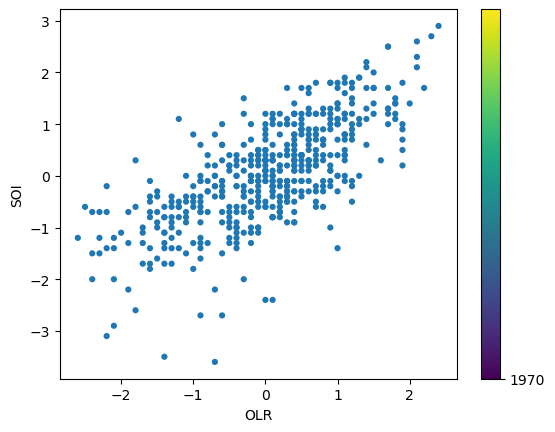

In [51]:
ax = df.plot(kind='scatter', x='OLR', y='SOI',
             colormap='viridis', colorbar=False, edgecolors='none')

plt.colorbar(ax.collections[0], ticks=mdates.YearLocator(5), 
             format=mdates.DateFormatter('%Y'))

## Fitting a line using numpy polyfit

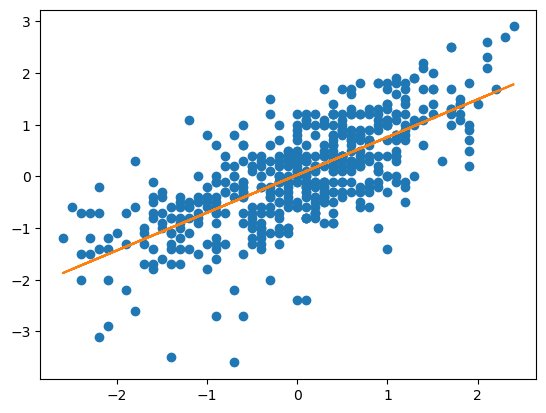

In [52]:
from numpy.polynomial import polynomial as P

x = df['OLR'].values
y = df['SOI'].values

idx = np.isfinite(x) & np.isfinite(y)

coefs, stats = P.polyfit(x[idx], y[idx], 1, full=True)

y2 = P.polyval(x, coefs)

plt.plot(x, y, linestyle='', marker='o')
plt.plot(x, y2)

plt.show()

## Exercise: rolling functions

**1. Subset data**

* Start by subsetting the SOI `DataFrame`
* Use either numerical indices, or, even better, datetime indices

In [53]:
# your code here

**2. Plot the subset data**

* You can create figure and axis using `matplotlib.pyplot`
* Or just use the `plot()` method of pandas `DataFrame`

In [54]:
# your code here

**3. Explore what `rolling()` method is**

* What does this method return?

In [55]:
# df.rolling?

In [56]:
# your code here

**4. Plot the original series and the smoothed series**

In [57]:
# your code here

# Concatenate

In [58]:
df1 = df[df.index <= datetime.datetime(1990,5,1)]
df2 = df[df.index > datetime.datetime(1990,5,1)]

pd.concat([df1, df2])

,OLR,SOI,mpl_date
Date,,,
1951-01-01,NaN,1.5,-6940.0
1951-02-01,NaN,0.9,-6909.0
1951-03-01,NaN,-0.1,-6881.0
1951-04-01,NaN,-0.3,-6850.0
1951-05-01,NaN,-0.7,-6820.0
...,...,...,...
2016-06-01,0.1,0.6,16953.0
2016-07-01,0.5,0.4,16983.0
2016-08-01,0.8,0.7,17014.0


# Merge

In [ ]:
df1

In [ ]:
df1 = df.copy()
df1.columns = ["OLR2", "SOI2","mpl_date2"]

pd.merge(left=df, right=df1, on="Date")

#  Groupby

In [ ]:
df_year = df.groupby(pd.Grouper(freq='Y')).mean()
df_month = df.groupby(pd.Grouper(freq='M')).mean()
df_6month = df.groupby(pd.Grouper(freq='6M')).mean()

plt.plot(df_month.OLR, color="blue", lw=0.5, label="Monthly mean")
plt.plot(df_6month.OLR, color="red", lw=1, label="6-monthly mean")
plt.plot(df_year.OLR, color="black", lw=2, label="Yearly mean")

plt.show()

In [ ]:
pd.date_range('2016/01/01', periods=16, freq='1M')

## References
* https://github.com/jonathanrocher/pandas_tutorial
* https://github.com/koldunovn/python_for_geosciences
* http://pandas.pydata.org/pandas-docs/stable/index.html#module-pandas
* http://pandas.pydata.org/pandas-docs/stable/10min.html